In [2]:
words=open('names.txt','r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

In [14]:
b={}
for w in words:
    chs=["<S>"]+list(w)+["<E>"]
    for ch1,ch2 in zip(chs,chs[1:]):
        biagram=(ch1,ch2)
        b[biagram]=b.get(biagram,0)+1

In [18]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [19]:
import torch

In [42]:
N=torch.zeros((27,27),dtype=torch.int32)

In [45]:
chars=sorted(list(set("".join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0

In [46]:
for w in words:
    chs=["."]+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1][ix2]+=1

In [47]:
itos={i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

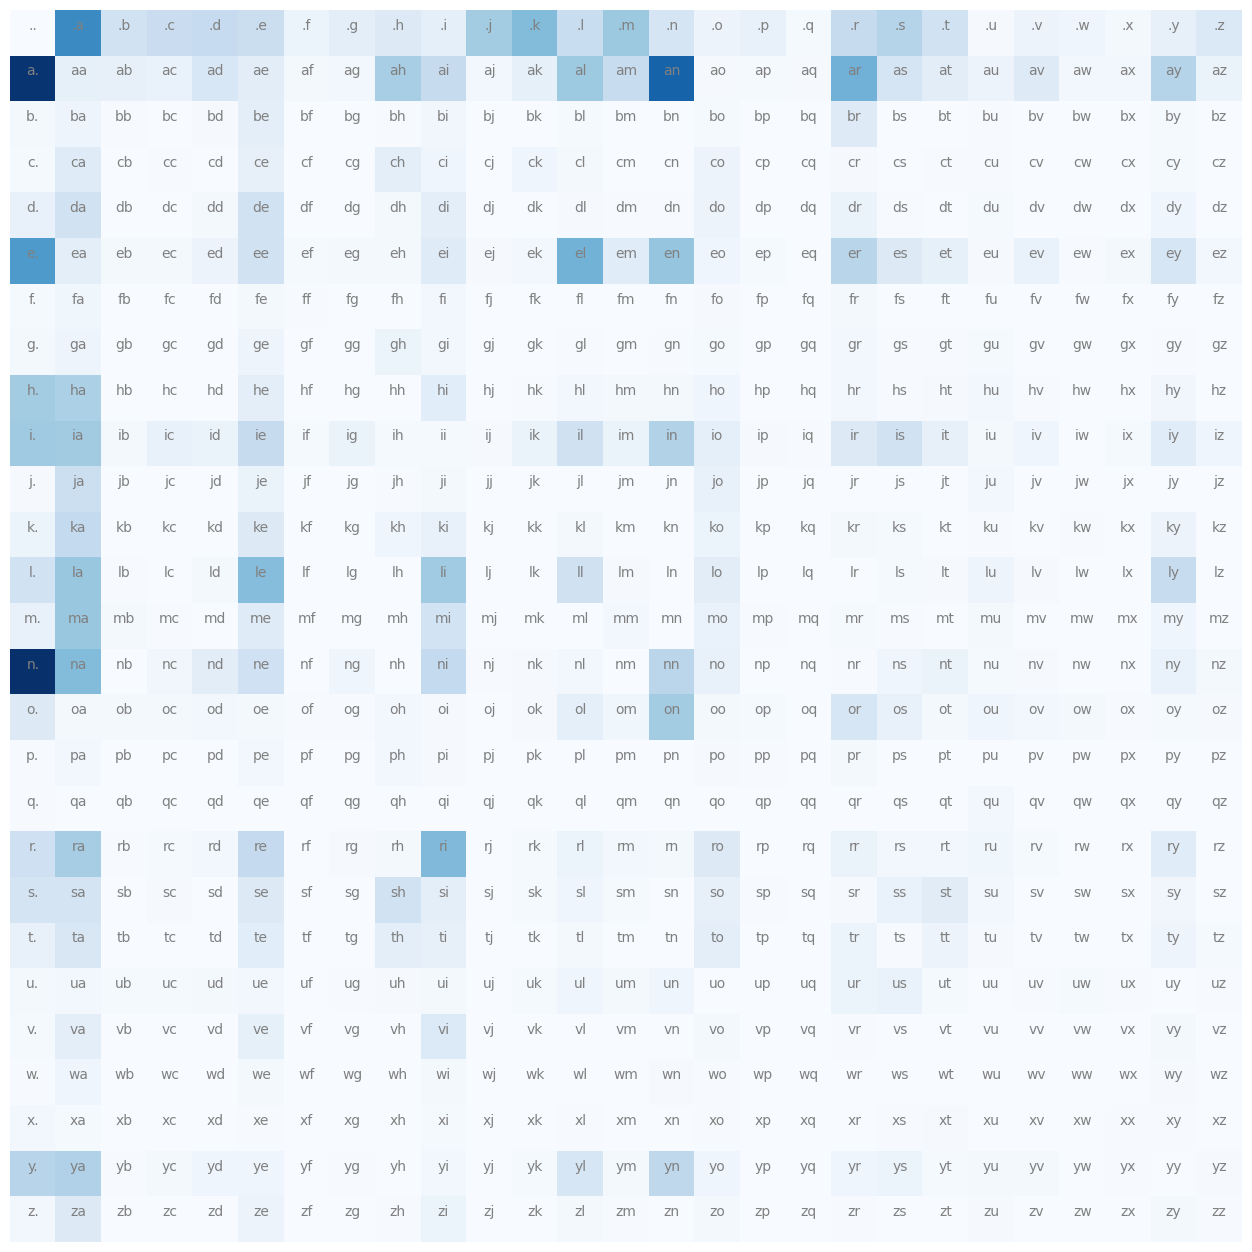

In [48]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr=itos[i]+itos[j]
        plt.text(j,i,chstr,ha='center', va='bottom', color='gray')
plt.axis('off')

In [54]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [67]:
p=N[0].float()
p/=p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [76]:
g=torch.Generator().manual_seed(2147483647)
ix=torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
itos[ix]

'l'

In [127]:
P=(N+5).float()
P/=P.sum(1,keepdim=True)

In [128]:
P[0].sum()

tensor(1.)

In [129]:
g=torch.Generator().manual_seed(2147483647)
for i in range(20):
    ix=0
    out=[]
    while True:
        #p=N[ix].float()
        #p=p/p.sum()
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print("".join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juwe.
ksahnaauranilevias.
dedainrwieta.
ssonielylarte.
faveumerifontume.
phynslenaruani.
core.
yaenon.
ka.
jabdinerimikimaynin.
anaasn.
ssorionsush.


In [130]:
log_likelihood=0.0
n=0
for w in words:
    chs=["."]+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob=P[ix1,ix2]
        logprob=torch.log(prob)
        log_likelihood+=logprob
        n+=1
        #print(f"{ch1}{ch2}: {prob:.4f} {logprob:.4f}")
print(log_likelihood)
nll=-log_likelihood
nll/n

tensor(-560645.1875)


tensor(2.4574)

In [138]:
xs,ys=[],[]
for w in words[:1]:
    chs=["."]+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs=torch.tensor(xs)
ys=torch.tensor(ys)

In [139]:
xs

tensor([ 0,  5, 13, 13,  1])

In [140]:
ys

tensor([ 5, 13, 13,  1,  0])

In [165]:
import torch.nn.functional as F
torch.set_printoptions(sci_mode=False)

In [166]:
xenc=F.one_hot(xs,num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [167]:
xenc.shape

torch.Size([5, 27])

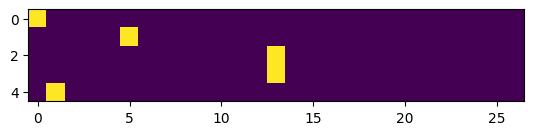

In [168]:
plt.imshow(xenc)

In [169]:
xenc.dtype

torch.float32

In [175]:
w=torch.randn((27,27))
logits=(xenc @ w)
counts=logits.exp()

In [178]:
prob=counts/counts.sum(1,keepdim=True)
prob

tensor([[0.0029, 0.0064, 0.0070, 0.0265, 0.0468, 0.0117, 0.0602, 0.0034, 0.1114,
         0.0109, 0.0351, 0.0331, 0.0185, 0.0035, 0.0448, 0.1049, 0.0199, 0.2059,
         0.0372, 0.0396, 0.0710, 0.0130, 0.0233, 0.0228, 0.0122, 0.0054, 0.0225],
        [0.0252, 0.0115, 0.0769, 0.0068, 0.1211, 0.0615, 0.0074, 0.1627, 0.0079,
         0.0040, 0.0255, 0.0374, 0.0659, 0.0064, 0.0290, 0.0594, 0.0144, 0.0358,
         0.0110, 0.0217, 0.0791, 0.0172, 0.0152, 0.0391, 0.0221, 0.0296, 0.0064],
        [0.0167, 0.1531, 0.0235, 0.0191, 0.0569, 0.0347, 0.0107, 0.0053, 0.0195,
         0.0373, 0.0563, 0.0284, 0.0083, 0.0169, 0.0177, 0.0235, 0.1064, 0.0439,
         0.0081, 0.1336, 0.0232, 0.0493, 0.0057, 0.0268, 0.0194, 0.0104, 0.0453],
        [0.0167, 0.1531, 0.0235, 0.0191, 0.0569, 0.0347, 0.0107, 0.0053, 0.0195,
         0.0373, 0.0563, 0.0284, 0.0083, 0.0169, 0.0177, 0.0235, 0.1064, 0.0439,
         0.0081, 0.1336, 0.0232, 0.0493, 0.0057, 0.0268, 0.0194, 0.0104, 0.0453],
        [0.0182, 0.0150,

In [186]:
g=torch.Generator().manual_seed(2147483647+1)
w=torch.randn((27,27), generator=g)

In [187]:
xenc=F.one_hot(xs,num_classes=27).float()
logits=xenc @ w
counts=logits.exp()
probs=counts/counts.sum(1,keepdims=True)

In [188]:
probs.shape

torch.Size([5, 27])

In [189]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()  # input character index
    y = ys[i].item()  # label character index

    print('----------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)

    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())

    logp = torch.log(p)
    print('log likelihood:', logp.item())

    nll = -logp
    print('negative log likelihood:', nll.item())

    nlls[i] = nll

print('==========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label (actual next character): 5
probability assigned by the net to the correct character: 0.05734505504369736
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
----------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label (actual next character): 13
probability assigned by the net to the correct character: 0.0145

In [190]:
xs

tensor([ 0,  5, 13, 13,  1])

In [191]:
ys

tensor([ 5, 13, 13,  1,  0])

In [221]:
g=torch.Generator().manual_seed(2147483647+1)
w=torch.randn((27,27), generator=g, requires_grad=True)

In [230]:
xenc=F.one_hot(xs,num_classes=27).float()
logits=xenc @ w
counts=logits.exp()
probs=counts/counts.sum(1,keepdims=True)

In [231]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [232]:
loss=-probs[torch.arange(5),ys].log().mean()
loss

tensor(3.3568, grad_fn=<NegBackward0>)

In [233]:
w.grad=None
loss.backward()

In [234]:
w.grad

tensor([[ 0.0010,  0.0191,  0.0056,  0.0140,  0.0192, -0.1883,  0.0048,  0.0027,
          0.0019,  0.0282,  0.0045,  0.0043,  0.0103,  0.0021,  0.0019,  0.0058,
          0.0046,  0.0055,  0.0065,  0.0055,  0.0089,  0.0100,  0.0043,  0.0019,
          0.0024,  0.0071,  0.0062],
        [-0.1850,  0.0042,  0.0095,  0.0110,  0.0013,  0.0028,  0.0033,  0.0010,
          0.0024,  0.0023,  0.0064,  0.0107,  0.0047,  0.0024,  0.0040,  0.0490,
          0.0018,  0.0071,  0.0011,  0.0077,  0.0013,  0.0053,  0.0035,  0.0037,
          0.0042,  0.0298,  0.0046],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [235]:
w.shape

torch.Size([27, 27])

In [236]:
w.grad.shape

torch.Size([27, 27])

In [229]:
w.data+=-0.1*w.grad

In [240]:
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [254]:

# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -60 * W.grad

2.480769395828247
2.480767250061035
2.4807651042938232
2.4807629585266113
2.4807605743408203
2.4807584285736084
2.4807562828063965
2.4807541370391846
2.4807522296905518
2.48075008392334
2.480747938156128
2.480745792388916
2.480743885040283
2.4807417392730713
2.4807398319244385
2.4807376861572266
2.4807357788085938
2.480733633041382
2.480731725692749
2.480729818344116
2.4807279109954834
2.4807257652282715
2.4807238578796387
2.480722188949585
2.480720281600952
2.4807186126708984
2.4807164669036865
2.4807145595550537
2.480713129043579
2.480710983276367
2.4807095527648926
2.4807076454162598
2.480705976486206
2.4807040691375732
2.4807024002075195
2.480700731277466
2.480699062347412
2.4806973934173584
2.4806957244873047
2.480694055557251
2.480692148208618
2.4806904792785645
2.48068904876709
2.480687379837036
2.4806857109069824
2.4806840419769287
2.480682611465454
2.4806811809539795
2.480679512023926
2.480678081512451
2.4806764125823975
2.480674982070923
2.48067307472229
2.4806718826293945
2.

In [256]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

junide.
janasah.
p.
cfay.
a.
nn.
kohin.
tolian.
juwe.
ksahnaauranilevias.
dedainrwieta.
ssonielylarte.
faveumerifontume.
phynslenaruani.
core.
yaenon.
ka.
jabdinerimikimaynin.
anaasn.
ssorionsush.
